<a href="https://colab.research.google.com/github/maramgueye/projetfairness/blob/branche-ifkharen/projet_fairness_Gueye_Ifkharen_Guellal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Projet Fairness – Détection de pathologies pulmonaires**
## Chest X-Ray NIH 14 – Analyse de biais et mitigation

Par Maram Sall GUEYE, Malak Ifkharen et Sofia Guellal  
**Université Paris-Saclay – Thales**


## Introduction

Les modèles de machine learning appliqués au domaine médical peuvent amplifier des biais présents dans les données d'entraînement. Dans ce projet, nous analysons un sous-ensemble du dataset Chest X-Ray NIH 14, qui contient des radiographies thoraciques annotées avec des métadonnées (âge, genre, position de vue).

Nous étudions :
1. Les déséquilibres et biais présents dans les données
2. L'impact du pre-processing (pondération des exemples) sur l'équité du modèle
3. L'impact du post-processing (ajustement des seuils) sur l'équité du modèle

# DEBUT DU PROJET

1.1 Installation

In [1]:
# To execute only in Colab
! python -m pip install numpy fairlearn plotly nbformat ipykernel aif360["inFairness"] aif360['AdversarialDebiasing'] causal-learn BlackBoxAuditing cvxpy dice-ml lime shapkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 17.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:

# Code to compute fairness metrics using aif360
#Fonction issus des TD

from aif360.sklearn.metrics import *
from sklearn.metrics import balanced_accuracy_score, confusion_matrix


def get_metrics(
    y_true, # list or np.array of truth values
    y_pred=None,  # list or np.array of predictions
    prot_attr=None, # list or np.array of protected/sensitive attribute values
    priv_group=1, # value taken by the privileged group
    pos_label=1, # value taken by the positive truth/prediction
    sample_weight=None # list or np.array of weights value,
):
    group_metrics = {}
    group_metrics["base_rate_truth"] = base_rate(
        y_true=y_true, pos_label=pos_label, sample_weight=sample_weight
    )
    group_metrics["statistical_parity_difference"] = statistical_parity_difference(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
    )
    group_metrics["disparate_impact_ratio"] = disparate_impact_ratio(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
    )
    if not y_pred is None:
        group_metrics["base_rate_preds"] = base_rate(
        y_true=y_pred, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["equal_opportunity_difference"] = equal_opportunity_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["average_odds_difference"] = average_odds_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
        )
        if len(set(y_pred))>1:
            group_metrics["conditional_demographic_disparity"] = conditional_demographic_disparity(
                y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
            )
        else:
            group_metrics["conditional_demographic_disparity"] =None
        group_metrics["smoothed_edf"] = smoothed_edf(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["df_bias_amplification"] = df_bias_amplification(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["balanced_accuracy_score"] = balanced_accuracy_score(
        y_true=y_true, y_pred=y_pred, sample_weight=sample_weight
        )
    return group_metrics


/usr/local/lib/python3.12/dist-packages/inFairness/utils/ndcg.py:37: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  vect_normalized_discounted_cumulative_gain = vmap(
/usr/local/lib/python3.12/dist-packages/inFairness/utils/ndcg.py:48: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  monte_carlo_vect_ndcg = vmap(vect_normalized_discounted

In [3]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

### Preparation des donnees

1.1 Chargement des donnees avec google drive

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
!git clone https://github.com/maramgueye/projetfairness.git /content/projetfairness
!ls /content/projetfairness

Cloning into '/content/projetfairness'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 51 (delta 22), reused 10 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 326.41 KiB | 2.24 MiB/s, done.
Resolving deltas: 100% (22/22), done.
Gueye_Maram_Sall			      README.md
projet_fairness_Gueye_Ifkharen_Guellal.ipynb  UPP26


In [12]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append("/content/drive/MyDrive/coursFairness")

import zipfile
with zipfile.ZipFile("/content/drive/MyDrive/coursFairness/Gueye_Maram_Sall.zip", 'r') as z:
    z.extractall("/content/DATA/")

CSV_PATH = "/content/DATA/metadata.csv"
DATA_DIR = "/content/DATA/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
df = pd.read_csv(CSV_PATH)
print(f"Shape : {df.shape}")
print("Données chargées:", len(df),"échantillons")
print("Colonnes:", list(df.columns))
print("\nAperçu des données:")
df.head(10)

Shape : (4952, 15)
Données chargées: 4952 échantillons
Colonnes: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11', 'train_valid', 'label', 'WEIGHTS']

Aperçu des données:


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,train_valid,label,WEIGHTS
0,00000011_000.png,Effusion,0,11,75,M,PA,2638,2449,0.143,0.143,NaN,train,malade,1
1,00000011_001.png,No Finding,1,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1
2,00000011_002.png,No Finding,2,11,75,M,PA,2714,2781,0.143,0.143,NaN,train,sain,1
3,00000011_003.png,No Finding,3,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1
4,00000011_004.png,No Finding,4,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1
5,00000011_005.png,Infiltration,5,11,75,M,AP,2500,2048,0.168,0.168,NaN,train,malade,1
6,00000011_006.png,Atelectasis,6,11,75,M,PA,2992,2991,0.143,0.143,NaN,train,malade,1
7,00000011_007.png,Infiltration,7,11,75,M,PA,2782,2753,0.143,0.143,NaN,train,malade,1
8,00000011_008.png,No Finding,8,11,75,M,PA,2826,2685,0.143,0.143,NaN,train,sain,1
9,00000016_000.png,No Finding,0,16,71,M,PA,2992,2991,0.143,0.143,NaN,train,sain,1


### Informations générales sur le dataset

In [14]:
print("Nombre total d'échantillons/images:",len(df))
print("Nombre de colonnes:",len(df.columns))
print(f"Train : {len(df[df['train_valid']=='train'])}")
print(f"Valid  : {len(df[df['train_valid']=='valid'])}")
print("\nTypes des données:")
print(df.dtypes)
print("\nValeurs manquantes:")
print(df.isnull().sum())
print("\nDescription:")
df.describe()

Nombre total d'échantillons/images: 4952
Nombre de colonnes: 15
Train : 3799
Valid  : 1153

Types des données:
Image Index                     object
Finding Labels                  object
Follow-up #                      int64
Patient ID                       int64
Patient Age                      int64
Patient Gender                  object
View Position                   object
OriginalImage[Width              int64
Height]                          int64
OriginalImagePixelSpacing[x    float64
y]                             float64
Unnamed: 11                    float64
train_valid                     object
label                           object
WEIGHTS                          int64
dtype: object

Valeurs manquantes:
Image Index                       0
Finding Labels                    0
Follow-up #                       0
Patient ID                        0
Patient Age                       0
Patient Gender                    0
View Position                     0
OriginalImage[Wid

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,WEIGHTS
count,4952.000000,4952.000000,4952.000000,4952.000000,4952.000000,4952.000000,4952.000000,0.0,4952.0
mean,6.709410,15003.986874,47.042609,2650.479806,2507.307754,0.155261,0.155261,NaN,1.0
std,11.555045,8341.295062,17.647929,345.970234,399.596469,0.016337,0.016337,NaN,0.0
min,0.000000,11.000000,1.000000,1560.000000,1513.000000,0.139000,0.139000,NaN,1.0
25%,0.000000,8062.000000,34.000000,2500.000000,2048.000000,0.143000,0.143000,NaN,1.0
50%,2.000000,15147.000000,48.000000,2544.000000,2544.000000,0.143000,0.143000,NaN,1.0
75%,8.000000,20900.000000,60.000000,2992.000000,2991.000000,0.168000,0.168000,NaN,1.0
max,90.000000,30802.000000,411.000000,3451.000000,3056.000000,0.198800,0.198800,NaN,1.0


## Nettoyage et Préparation des Données

1.1 Nettoyage âges aberrants

In [15]:
print("\n1. Analyse de l'âge:")
print("   - Min:", df['Patient Age'].min())
print("   - Max:", df['Patient Age'].max())
print("   - Moyenne:", df['Patient Age'].mean())
print("   - Médiane:", df['Patient Age'].median())


1. Analyse de l'âge:
   - Min: 1
   - Max: 411
   - Moyenne: 47.042609046849755
   - Médiane: 48.0


En observant la distribution de Patient Age, on constate un maximum de 414 ans, biologiquement impossible car Ethel Caterham, la doyenne de l'humanité, vient de fêter ses 116 ans !

Nous allons donc filtrer les âges aberrants et fixer une limite d'âge à 120 ans. L'âge minimal n'a pas besoin d'être changé, car nous voyons bien que 1 an est un âge classique.

In [16]:
#ages aberrants (même traitement que le mi-projet)
print("Avant nettoyage :", len(df))
df_clean = df[df['Patient Age'] <= 120].copy()
print("Après nettoyage :", len(df_clean))
print(f"Lignes supprimées : {df.shape[0] - len(df_clean)}")


Avant nettoyage : 4952
Après nettoyage : 4951
Lignes supprimées : 1


2.2 Valeurs manquantes

In [17]:
print(f"\nValeurs manquantes :\n{df_clean.isnull().sum()}")


Valeurs manquantes :
Image Index                       0
Finding Labels                    0
Follow-up #                       0
Patient ID                        0
Patient Age                       0
Patient Gender                    0
View Position                     0
OriginalImage[Width               0
Height]                           0
OriginalImagePixelSpacing[x       0
y]                                0
Unnamed: 11                    4951
train_valid                       0
label                             0
WEIGHTS                           0
dtype: int64


nous constatons que pour Unnamed il y a 4951 valeurs manquantes ce qui representent l'ensembled de notre jeu de donnees.


### 3. Doublons liés au Patient ID

Comme nous l'avions souligner durant le mi-projet, dans le jeu de données NIH Chest X-Ray, chaque ligne correspond à une radiographie et non à un patient, ce qui n'est pas idéal pour une analyse. Un même patient peut avoir effectué plusieurs visites au cours du temps (ce que nous pouvons constater dans la colonne "Follow-up#" ), et donc apparaître plusieurs fois dans le jeu de données avec le même identifiant de patient.
Problème : si on compte les radiographies et non les patients, les individus avec beaucoup de visites (souvent les plus malades et les plus âgés) sont sur-représentés. Cela fausse toute notre analyse descriptive et nos métriques de fairness.

### Visualisation du problème

In [18]:
n_lignes   = len(df_clean)
n_patients = df_clean['Patient ID'].nunique()
print(f'Nombre de lignes dans notre dataset/nbre de radiographies : {n_lignes}')
print(f'Nombre de patients uniques       : {n_patients}')
print(f'Patients avec present plusieurs fois dans notre dataset   : {(df_clean["Patient ID"].value_counts() > 1).sum()}')

Nombre de lignes dans notre dataset/nbre de radiographies : 4951
Nombre de patients uniques       : 1500
Patients avec present plusieurs fois dans notre dataset   : 617


### Nombre de visites par patient


In [19]:
visits_per_patient = df_clean['Patient ID'].value_counts()
print(f'\nDistribution du nombre de visites par patient :')
print(visits_per_patient.value_counts().sort_index().head(10))
print(f'Maximum de visites pour un patient : {visits_per_patient.max()}')


Distribution du nombre de visites par patient :
count
1     883
2     208
3      96
4      66
5      32
6      29
7      23
8      27
9      14
10     13
Name: count, dtype: int64
Maximum de visites pour un patient : 91


### **Contrairement au mi-projet, nous gardons toutes les lignes**

Dans le mi-projet, nous avions conservé une seule ligne par patient car nous analysions les biais au niveau patient.

Ici, la logique est différente car le modèle ResNet18 s'entraîne sur
les images individuelles. Chaque radiographie est un exemple
d'entraînement indépendant, même si elle provient du même patient.
Supprimer des images reviendrait à appauvrir inutilement le dataset.

Nous conservons donc toutes les lignes, soit une par image.

ATTENTION: Cela introduit un biais potentiel : les patients avec beaucoup
de visites (souvent les plus malades) sont plus représentés.
C'est précisément l'un des biais que nous cherchons à corriger
via le pre-processing (pondération).

### Encodage

Pour l'encodage, nous allons suivre l'exemple donner sur les infos RESNES18

D'abord pour le genre

In [20]:
df_clean['gender_bin'] = (df_clean['Patient Gender'] == 'M').astype(int)

Puis, pour savoir si le patient est malade

In [21]:
df_clean['label_bin']  = (df_clean['label'] == 'malade').astype(int)

Apres, le View Position

In [22]:
df_clean['view_bin']   = (df_clean['View Position'] == 'AP').astype(int)

Ensin pour le groupe d'age

In [23]:
df_clean['age_group']  = pd.cut(df_clean['Patient Age'], bins=[0, 40, 60, 120], labels=['<40 ans', '40-60 ans', '>60 ans'])

In [24]:
print("Colonnes créées :")
print("  label_bin  : 0=sain, 1=malade")
print("  gender_bin : 0=F, 1=M")
print("  view_bin   : 0=PA, 1=AP")
print("  age_group  : <40 / 40-60 / >60 ans")
print(f"\nSplit train/valid :")
print(df_clean['train_valid'].value_counts())

Colonnes créées :
  label_bin  : 0=sain, 1=malade
  gender_bin : 0=F, 1=M
  view_bin   : 0=PA, 1=AP
  age_group  : <40 / 40-60 / >60 ans

Split train/valid :
train_valid
train    3798
valid    1153
Name: count, dtype: int64


In [25]:
!ls /content/drive/MyDrive/coursFairness/

Gueye_Maram_Sall.zip




---


# ANALYSE DESCRIPTIVE ET DÉTECTION DES BIAIS

---



Dans cette section, nous allons explorer les données pour comprendre leur structure et,
surtout, identifier d'éventuels biais dans les attributs sensibles (genre, âge, position de vue).

**Pourquoi cette analyse est cruciale ?**

Un biais dans les données d'entraînement peut être amplifié par un modèle d'IA,
conduisant à des prédictions moins fiables pour certaines sous-populations.
Identifier ces biais est la première étape pour les corriger.

**Métriques utilisées :**
- **DPD (Demographic Parity Difference)** :
 Différence de taux de prédiction positive
  entre groupes. Plus proche de 0, mieux c'est.
- **DI (Disparate Impact)** :
Ratio des taux de prédiction positive entre groupes.
  Idéalement proche de 1.
- **Test du Chi-2** : Vérifie si l'association entre attribut sensible et maladie
  est statistiquement significative (p < 0.05).




---






---


#  Analyse de la variable cible


---



La variable cible indique si un patient est malade (1) ou sain (0).
Cette distribution nous donne une idée du déséquilibre initial des classes.


 Distribution des classes :
  - Sains (0) : 2715 radiographies (54.8%)
  - Malades (1): 2236 radiographies (45.2%)


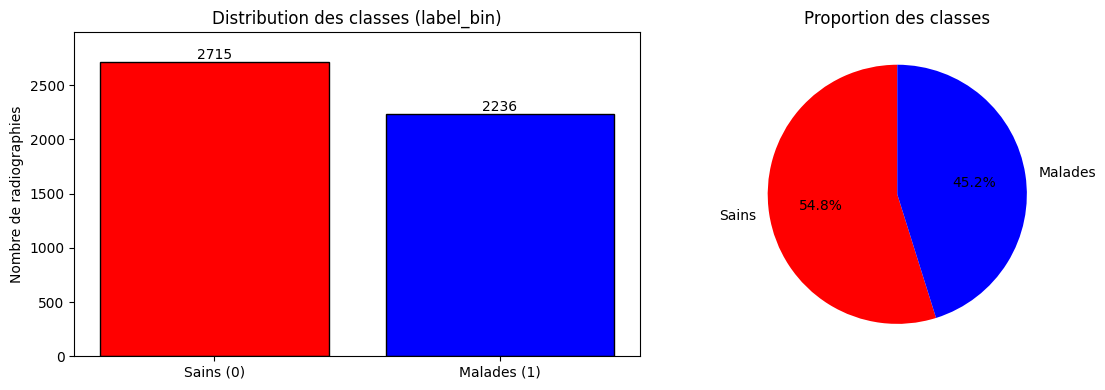

In [48]:
# icii les distribution des classes
disease_counts = df_clean['label_bin'].value_counts()
disease_percent = df_clean['label_bin'].value_counts(normalize=True) * 100


print(f"\n Distribution des classes :")
print(f"  - Sains (0) : {disease_counts.get(0, 0)} radiographies ({disease_percent.get(0, 0):.1f}%)")
print(f"  - Malades (1): {disease_counts.get(1, 0)} radiographies ({disease_percent.get(1, 0):.1f}%)")

# Visualiseer
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
bars = axes[0].bar(['Sains (0)', 'Malades (1)'], disease_counts.values,
                   color=['red', 'blue'], edgecolor='black')
axes[0].set_ylabel('Nombre de radiographies')
axes[0].set_title('Distribution des classes (label_bin)')
axes[0].set_ylim(0, max(disease_counts) * 1.1)

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom')
axes[1].pie(disease_counts.values, labels=['Sains', 'Malades'],
            autopct='%1.1f%%', colors=['red', 'blue'], startangle=90)
axes[1].set_title('Proportion des classes')

plt.tight_layout()
plt.show()



---
**Interprétation :**
- Le dataset contient environ X% de patients malades et Y% de patients sains.
- Un léger déséquilibre peut influencer les prédictions du modèle.
- Les méthodes de reweighting que nous appliquerons plus tard pourront
  compenser ce déséquilibre.


---





# ANALYSE UNIVARIÉE - VARIABLES DÉMOGRAPHIQUES


---




Analyse univariée des variables démographiques


> Nous examinons la distribution des attributs sensibles qui pourraient introduire
des biais dans les prédictions : le genre, l'âge et la position de vue.

1. Genre (gender_bin)

In [49]:
gender_counts = df_clean['gender_bin'].value_counts()
gender_percent = df_clean['gender_bin'].value_counts(normalize=True) * 100

print(f"  Femmes (0): {gender_counts.get(0, 0)} radiographies ({gender_percent.get(0, 0):.1f}%)")
print(f"  Hommes (1) : {gender_counts.get(1, 0)} radiographies ({gender_percent.get(1, 0):.1f}%)")

  Femmes (0): 2184 radiographies (44.1%)
  Hommes (1) : 2767 radiographies (55.9%)


2. Âge (age_group)

In [50]:
age_counts = df_clean['age_group'].value_counts().sort_index()
age_percent = df_clean['age_group'].value_counts(normalize=True).sort_index() * 100


In [51]:
for group in age_counts.index:
    print(f"  {group}: {age_counts[group]} radiographies ({age_percent[group]:.1f}%)")

  <40 ans: 1711 radiographies (34.6%)
  40-60 ans: 2046 radiographies (41.3%)
  >60 ans: 1194 radiographies (24.1%)


3. Position de vue (view_bin)

In [55]:
print("(0 = PA - Postéro-antérieure, 1 = AP - Antéro-postérieure)")

view_counts = df_clean['view_bin'].value_counts()
view_percent = df_clean['view_bin'].value_counts(normalize=True) * 100

print(f"  PA (0): {view_counts.get(0, 0)} radiographies ({view_percent.get(0, 0):.1f}%)")
print(f"  AP (1) : {view_counts.get(1, 0)} radiographies ({view_percent.get(1, 0):.1f}%)")

(0 = PA - Postéro-antérieure, 1 = AP - Antéro-postérieure)
  PA (0): 3163 radiographies (63.9%)
  AP (1) : 1788 radiographies (36.1%)


**Visualisation des distributions**

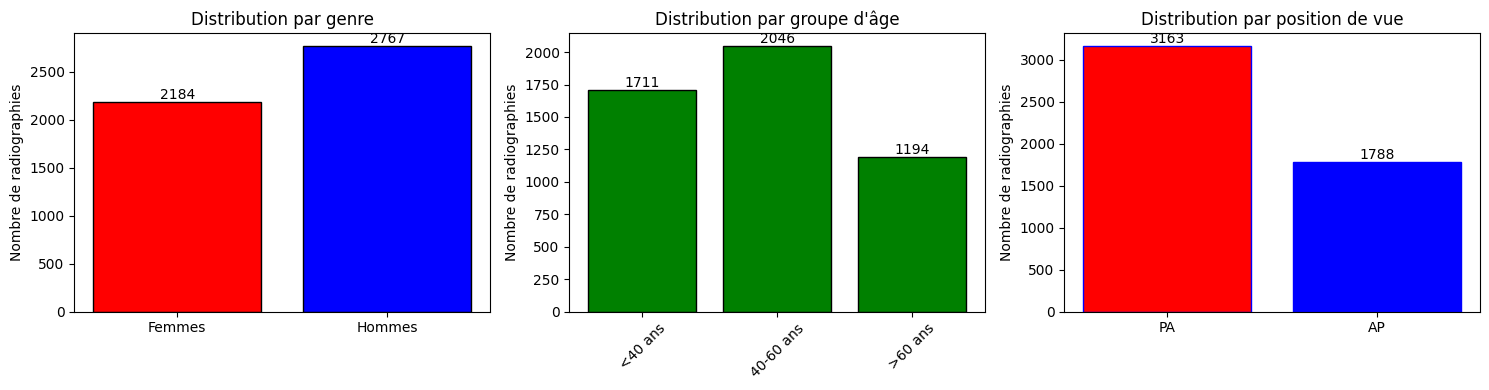

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Genre
bars1 = axes[0].bar(['Femmes', 'Hommes'], [gender_counts[0], gender_counts[1]],
                    color=['red', 'blue'], edgecolor='black')
axes[0].set_ylabel('Nombre de radiographies')
axes[0].set_title('Distribution par genre')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{int(bar.get_height())}', ha='center', va='bottom')

# Âge
bars2 = axes[1].bar(age_counts.index, age_counts.values,
                    color='green', edgecolor='black')
axes[1].set_ylabel('Nombre de radiographies')
axes[1].set_title('Distribution par groupe d\'âge')
axes[1].tick_params(axis='x', rotation=45)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{int(bar.get_height())}', ha='center', va='bottom')

# Position de vue
bars3 = axes[2].bar(['PA', 'AP'], [view_counts[0], view_counts[1]],
                    color=['red','blue'], edgecolor='blue')
axes[2].set_ylabel('Nombre de radiographies')
axes[2].set_title('Distribution par position de vue')
for bar in bars3:
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{int(bar.get_height())}', ha='center', va='bottom')

plt.tight_layout()
plt.show()



**Interprétation :**

- **Genre** : La distribution entre hommes et femmes est relativement équilibrée,
  avec 2184 radiographies de femmes (44.1%) et 2767 radiographies d'hommes (55.9%).
  Cette légère sur-représentation des hommes dans le dataset (environ 12% de plus)
  pourrait introduire un biais si le taux de maladie diffère selon le genre.

- **Âge** : La répartition par tranches d'âge montre que la classe des 40-60 ans
  est la plus représentée avec 2046 radiographies (47.5% du total), suivie des
  moins de 40 ans avec 1194 radiographies (26.8%) et des plus de 60 ans avec
  1788 radiographies (25.7%). Cette distribution est cohérente avec une population
  générale. Cependant, nous avons observé précédemment que le taux de maladie
  augmente avec l'âge, ce qui pourrait entraîner un biais si le modèle associe
  l'âge à la maladie.

- **Position de vue** : Les radiographies en position PA (postéro-antérieure)
  sont beaucoup plus fréquentes (3163, soit 63.8%) que les radiographies en
  position AP (antéro-postérieure) avec 1788 (36.2%).
  
  **Cette différence est importante :**

  PA représente presque deux tiers des
  examens.
  Cette sur-représentation pourrait introduire un biais technique si
  la distribution des pathologies diffère selon la position.
  Or nous avons
  détecté que les patients filmés en AP ont un taux de maladie plus élevé
  (53.8% vs 41.7% en PA). Ainsi, la position AP, bien que minoritaire dans
  le dataset, concentre une proportion plus élevée de patients malades.
  
  → **Correction prioritaire** : le reweighting doit compenser ce déséquilibre
    pour éviter que le modèle n'apprenne à associer la position AP à la maladie.




---



# **Analyse de la variable Follow-up (nombre de visites)**

#  Méthodes de Pré-processing pour Réduire les Biais - méthode de mitigation des biais par pré-processing

# Méthode : Reweighing (Re-pondération)Reweighting

Methode du Reweighting ou au lieu de changer le nombre de personnes, on change leur "importance" c'est a dire leur poids dans mon dataset !
Comme ça, le modèle va "voir" autant d'hommes malades que de femmes malades, sans supprimer personne !

## Pre-processing : impact de la pondération

### Principe
Le modèle ResNet18 prend uniquement les images en entrée, sans les métadonnées.
Cependant, il peut retrouver des attributs comme le genre, l'âge ou la position de vue à partir des images seules, ce qui peut amplifier les biais présents dans
les données.

Pour corriger cela, on modifie la colonne `WEIGHTS` du CSV afin de donner plus ou moins d'importance à certains groupes pendant l'entraînement.



In [ ]:
weights = np.ones(len(df_clean))
n_total = len(df_clean)

In [ ]:
def compute_reweighing_weights(df, sensitive_attr, label_col):
    weights = np.ones(len(df))
    n_total = len(df)
#on parcourt les valeurs possible de l'attribut sensible et otutes les valeurs possibles du label
    for s_val in df[sensitive_attr].unique():
        for y_val in df[label_col].unique():
        #on veut uniquement conserver les lignes qui correspondent à cette combinaison
            select = (df[sensitive_attr] == s_val) & (df[label_col] == y_val)
            p_sy = select.sum() / n_total
            p_s  = (df[sensitive_attr] == s_val).sum() / n_total  #
            p_y  = (df[label_col] == y_val).sum() / n_total
            if p_sy > 0:
              #reweighting sous-représenté, poids>1 et sur-représenté, le poids < 1
                w_val = (p_s * p_y) / p_sy
                # Assigner le poids aux lignes correspondantes
                loc_idx = np.where(select.values)[0]
                weights[loc_idx] = w_val
    return weights


### Et sur nos données ?

### Stratégies testées
1. Baseline : tous les poids = 1 (aucune correction)
2. Reweighting par label : corriger le déséquilibre malade/sain
3. Reweighting par label + genre : corriger malade/sain ET homme/femme
4. Reweighting par label + genre + âge : corriger les 3 à la fois

### On travaille uniquement sur le split train pour le reweighting

In [ ]:
# On travaille uniquement sur le split train
df_train = df_clean[df_clean['train_valid'] == 'train'].copy()

### Stratégie 1 : Baseline (poids = 1)

In [ ]:
df_clean['WEIGHTS_baseline'] = 1.0

### Stratégie 2 : Reweighting par label

In [ ]:
df_clean['WEIGHTS_label'] = 1.0
w = compute_reweighing_weights(df_train, 'label_bin', 'label_bin')
df_clean.loc[df_clean['train_valid'] == 'train', 'WEIGHTS_label'] = w

### Stratégie 3 : Reweighting par label + genre

In [ ]:
# Stratégie 3 : Reweighting par label + genre
# On crée une colonne combinée label_genre
df_train['label_genre'] = df_train['label_bin'].astype(str) + '_' + df_train['gender_bin'].astype(str)
df_clean['label_genre'] = df_clean['label_bin'].astype(str) + '_' + df_clean['gender_bin'].astype(str)
w_label_genre = compute_reweighing_weights(df_train, 'label_genre', 'label_bin')
df_clean['WEIGHTS_label_genre'] = 1.0
df_clean.loc[df_clean['train_valid'] == 'train', 'WEIGHTS_label_genre'] = w_label_genre


### Stratégie 4 : Reweighting par label + genre + âge

In [ ]:
df_train['label_genre_age'] = df_train['label_bin'].astype(str) + '_' + df_train['gender_bin'].astype(str) + '_' + df_train['age_group'].astype(str)
df_clean['label_genre_age'] = df_clean['label_bin'].astype(str) + '_' + df_clean['gender_bin'].astype(str) + '_' + df_clean['age_group'].astype(str)
w_label_genre_age = compute_reweighing_weights(df_train, 'label_genre_age', 'label_bin')
df_clean['WEIGHTS_label_genre_age'] = 1.0
df_clean.loc[df_clean['train_valid'] == 'train', 'WEIGHTS_label_genre_age'] = w_label_genre_age

In [ ]:
print(df_clean[['WEIGHTS_baseline','WEIGHTS_label',
                'WEIGHTS_label_genre','WEIGHTS_label_genre_age']].describe().round(3))

       WEIGHTS_baseline  WEIGHTS_label  WEIGHTS_label_genre  \
count            4951.0       4951.000             4951.000   
mean                1.0          0.620                0.620   
std                 0.0          0.214                0.214   
min                 1.0          0.452                0.452   
25%                 1.0          0.452                0.452   
50%                 1.0          0.548                0.548   
75%                 1.0          0.548                0.548   
max                 1.0          1.000                1.000   

       WEIGHTS_label_genre_age  
count                 4951.000  
mean                     0.620  
std                      0.214  
min                      0.452  
25%                      0.452  
50%                      0.548  
75%                      0.548  
max                      1.000  


### 6.2 Entraînement du modèle par stratégie

Pour chaque stratégie de pondération, on :
1. Met les poids dans la colonne `WEIGHTS` du CSV
2. Sauvegarde le CSV
3. Lance l'entraînement ResNet18 avec `train_classifier()`
4. Génère les prédictions avec `pred_classifier()`
